<a href="https://colab.research.google.com/github/Chandini-M555/Data_Science_Task/blob/main/Heart_Disease_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
df=pd.read_csv("heart.csv")
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.keys()

Index(['Unnamed: 0', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df["heart_disease"]=df.target
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,1


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0


<Axes: xlabel='heart_disease', ylabel='Count'>

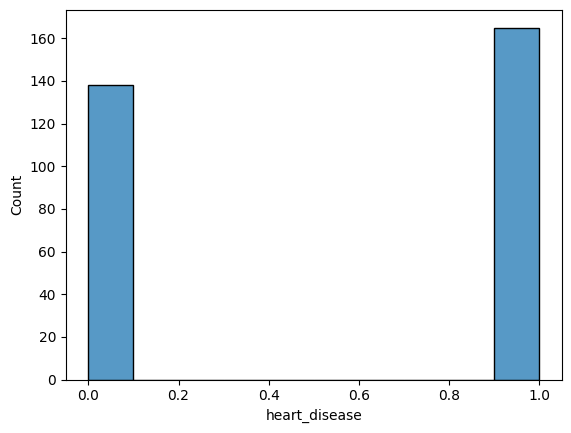

In [ ]:
sns.histplot(x="heart_disease",data=df)

<Axes: xlabel='sex', ylabel='Count'>

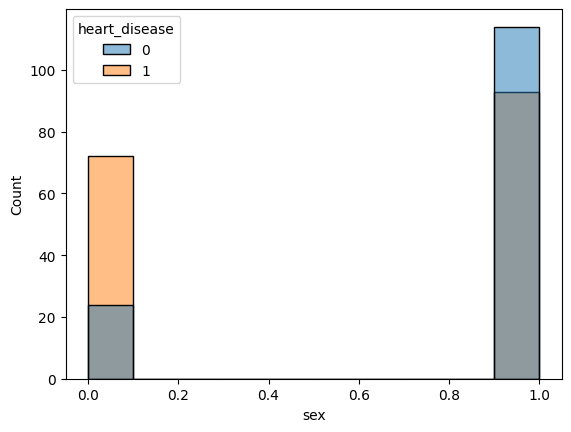

In [ ]:
sns.histplot(x="sex",data=df,hue="heart_disease")

([<matplotlib.patches.Wedge at 0x795c16b1e690>,
 [Text(-0.15346694397759053, 1.0892418909985877, 'male'),
  Text(0.15346716904989344, -1.0892418592873723, 'female')],
 [Text(-0.08370924216959483, 0.5941319405446842, '54.46%'),
  Text(0.0837093649363055, -0.5941319232476575, '45.54%')])

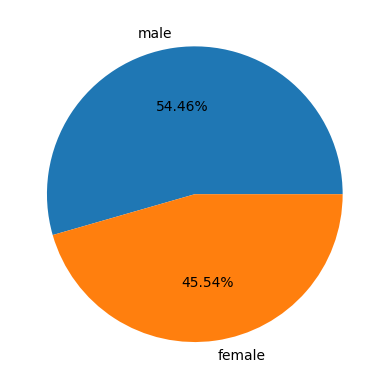

In [ ]:
#using piechart who is having cancer count more
df.heart_disease.value_counts()
plt.pie(df.heart_disease.value_counts(),labels=["male","female"],autopct="%0.2f%%")


<Axes: xlabel='trestbps', ylabel='Count'>

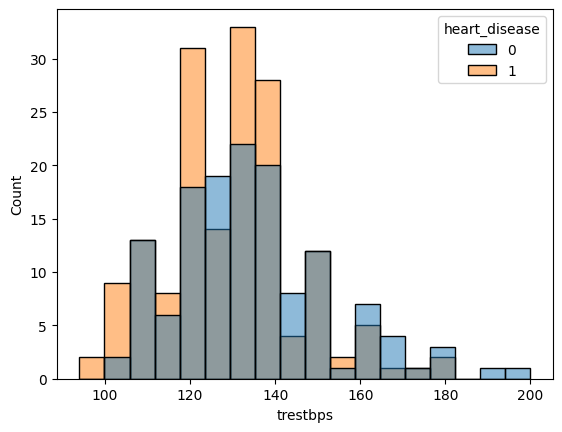

In [ ]:
#histplot about trestbps vs heartdisease
sns.histplot(x="trestbps",data=df,hue="heart_disease")

<Axes: xlabel='age', ylabel='Count'>

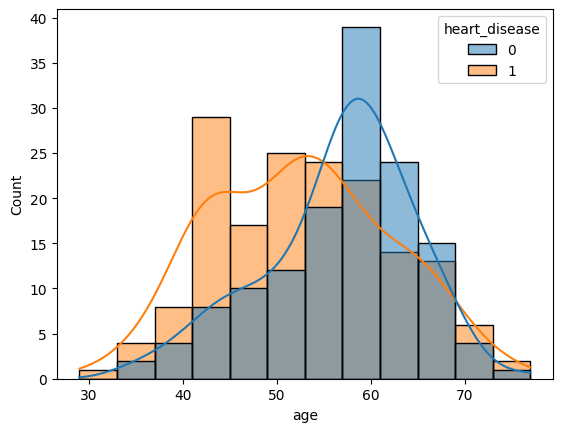

In [ ]:
sns.histplot(x="age",data=df,hue="heart_disease",kde=True)

# Model Training

In [ ]:
#dividing input and output
X=df.drop(["heart_disease","Unnamed: 0"],axis=1)
Y=df.heart_disease

In [ ]:
#split data for training nd testing
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
#Logistic regression
model=LogisticRegression()
model.fit(Xtrain,Ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
ypred=model.predict(Xtest)

In [ ]:
confusion_matrix(Ytest,ypred)

array([[29,  0],
       [ 0, 32]])

In [ ]:
print(classification_report(Ytest,ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        32

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



In [ ]:
print("training eff: ",model.score(Xtrain,Ytrain))
print("testing eff: ",model.score(Xtest,Ytest))

training eff:  1.0
testing eff:  1.0


In [ ]:
#new input
new_data=df.iloc[:1,:-1]
pred=model.predict(new_data)
prob=model.predict_proba(new_data)
if pred==0:
  print("no cancer")
else:
  print("yes cancer")
print("probability: ",prob)